In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import glob
from scipy.stats import linregress
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split


# select demand for victoria and sort in order of date
#demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/VIC_clean.csv")
demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/master_data.csv")

demand.sort()

df_list = [pd.read_csv(f) for f in demand]
if df_list:
    print("CSV files loaded")
else:
    print("No CSV files were loaded.")


df = pd.concat(df_list, ignore_index=True)

# Parse datetime column
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%Y/%m/%d %H:%M")

# Extract hour of the day
df['Hour'] = df['Datetime'].dt.hour

# Extract year column
df['Year'] = df['Datetime'].dt.year

df['Day'] = df['Datetime'].dt.day_name()



CSV files loaded


Columns in df: ['State', 'Datetime', 'Total Demand', 'RRP', 'Precipitation (mm)', 'Air Temp (C)', 'Humidity (%)', 'Wind Speed (km/h)', 'Hour', 'Year', 'Day']

Unique values in potential region/state columns:
State: ['NSW' 'QLD' 'SA' 'TAS' 'VIC']
Demand columns not found. Check with df.columns and adjust.


KeyError: 'Region'

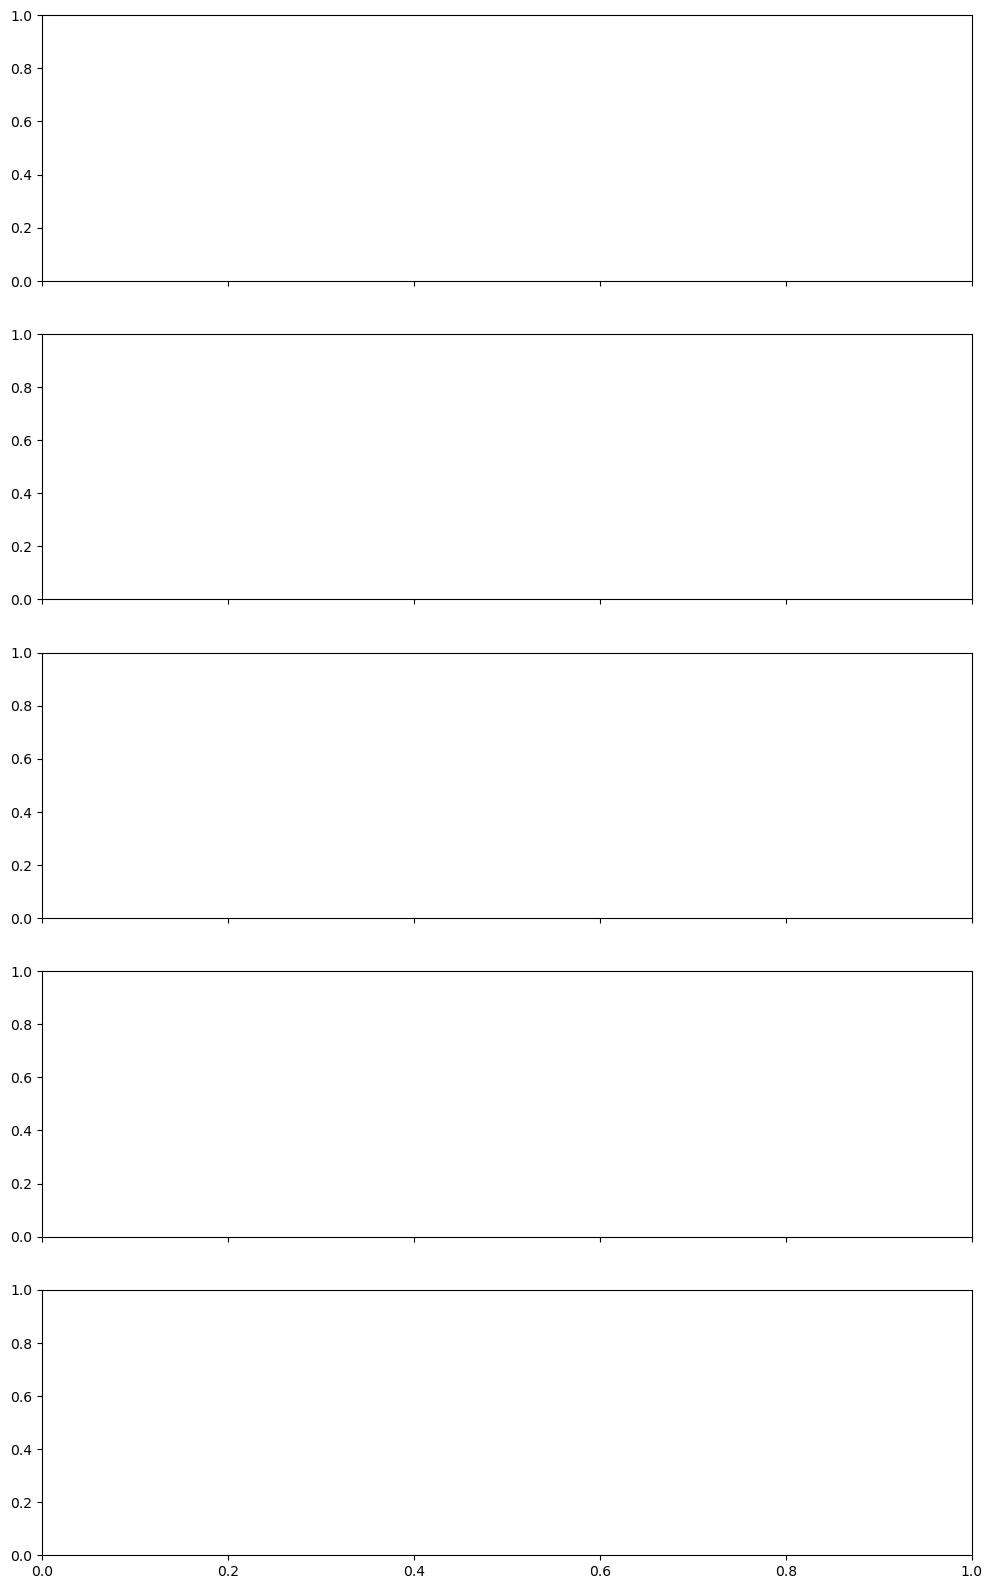

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# First, let's inspect the actual columns and unique regions/states in your df
print("Columns in df:", df.columns.tolist())
print("\nUnique values in potential region/state columns:")
for col in df.columns:
    if 'region' in col.lower() or 'state' in col.lower() or col == 'Region':
        print(f"{col}: {df[col].unique()[:10]}")  # Print first 10 unique values

# Assuming from your filename 'VIC_clean.csv' and 'master_data.csv', the data might be for a single state or have separate demand columns.
# Common in AEMO-like datasets: separate columns like 'NSW Demand', 'VIC Demand', etc., or a 'REGIONID' column.

# Option 1: If there's a 'REGIONID' or similar column (common in AEMO data), replace 'Region' with that.
# For example:
# states = ['NSW1', 'VIC1', 'QLD1', 'SA1', 'TAS1']  # Adjust based on print output above
# Then use: state_df = df[df['REGIONID'] == state]

# Option 2: If demand is in separate columns per state (e.g., 'NSW_Demand', 'VIC_Demand'), pivot or melt.
# Let's assume columns like 'TOTALDEMAND' and a region column – or provide code to melt if needed.

# If master_data.csv has data for all states in long format, or wide?
# For now, here's adapted code assuming a 'REGION' column (case sensitive) or adjust.
# If not, let's melt assuming separate demand columns.

# Example adaptation if separate columns: Suppose columns are 'NSW', 'VIC', 'QLD', 'SA', 'TAS' for demands.
demand_columns = ['NSW', 'VIC', 'QLD', 'SA', 'TAS']  # Adjust to actual demand column names per state, e.g., ['NSW_Demand', ...]

# If the df has 'Datetime', 'Year' and state-specific demand columns, melt it to long format
if all(col in df.columns for col in demand_columns):
    df_melted = df.melt(id_vars=['Year'], value_vars=demand_columns, 
                        var_name='Region', value_name='Total Demand')
    print("Melted df for multi-state plotting.")
else:
    print("Demand columns not found. Check with df.columns and adjust.")
    df_melted = df  # Fallback, will fail later

states = demand_columns  # Or ['NSW', 'VIC', etc.]

# Now plot using df_melted
fig, axes = plt.subplots(nrows=5, ncols=1, figsize=(12, 20), sharex=True)

for ax, state in zip(axes, states):
    # Filter
    state_df = df_melted[df_melted['Region'] == state]
    
    # Average by year
    avg_demand_by_year = state_df.groupby('Year')['Total Demand'].mean().reset_index()
    avg_demand_by_year['Year'] = avg_demand_by_year['Year'].astype(int)
    
    # Plot
    ax.scatter(avg_demand_by_year['Year'], avg_demand_by_year['Total Demand'], 
               color='black', s=50, alpha=0.8, label='Average Demand')
    ax.plot(avg_demand_by_year['Year'], avg_demand_by_year['Total Demand'], 
            color='black', linewidth=2, linestyle='--', label='Trend Line')
    
    ax.set_title(f'Average Energy Demand by Year in {state}', fontsize=14)
    ax.set_ylabel('Average Total Demand (MW)', fontsize=12)
    ax.grid(True, axis='y')
    ax.legend()
    ax.set_xticks(avg_demand_by_year['Year'])

axes[-1].set_xlabel('Year', fontsize=12)
plt.tight_layout()
plt.show()

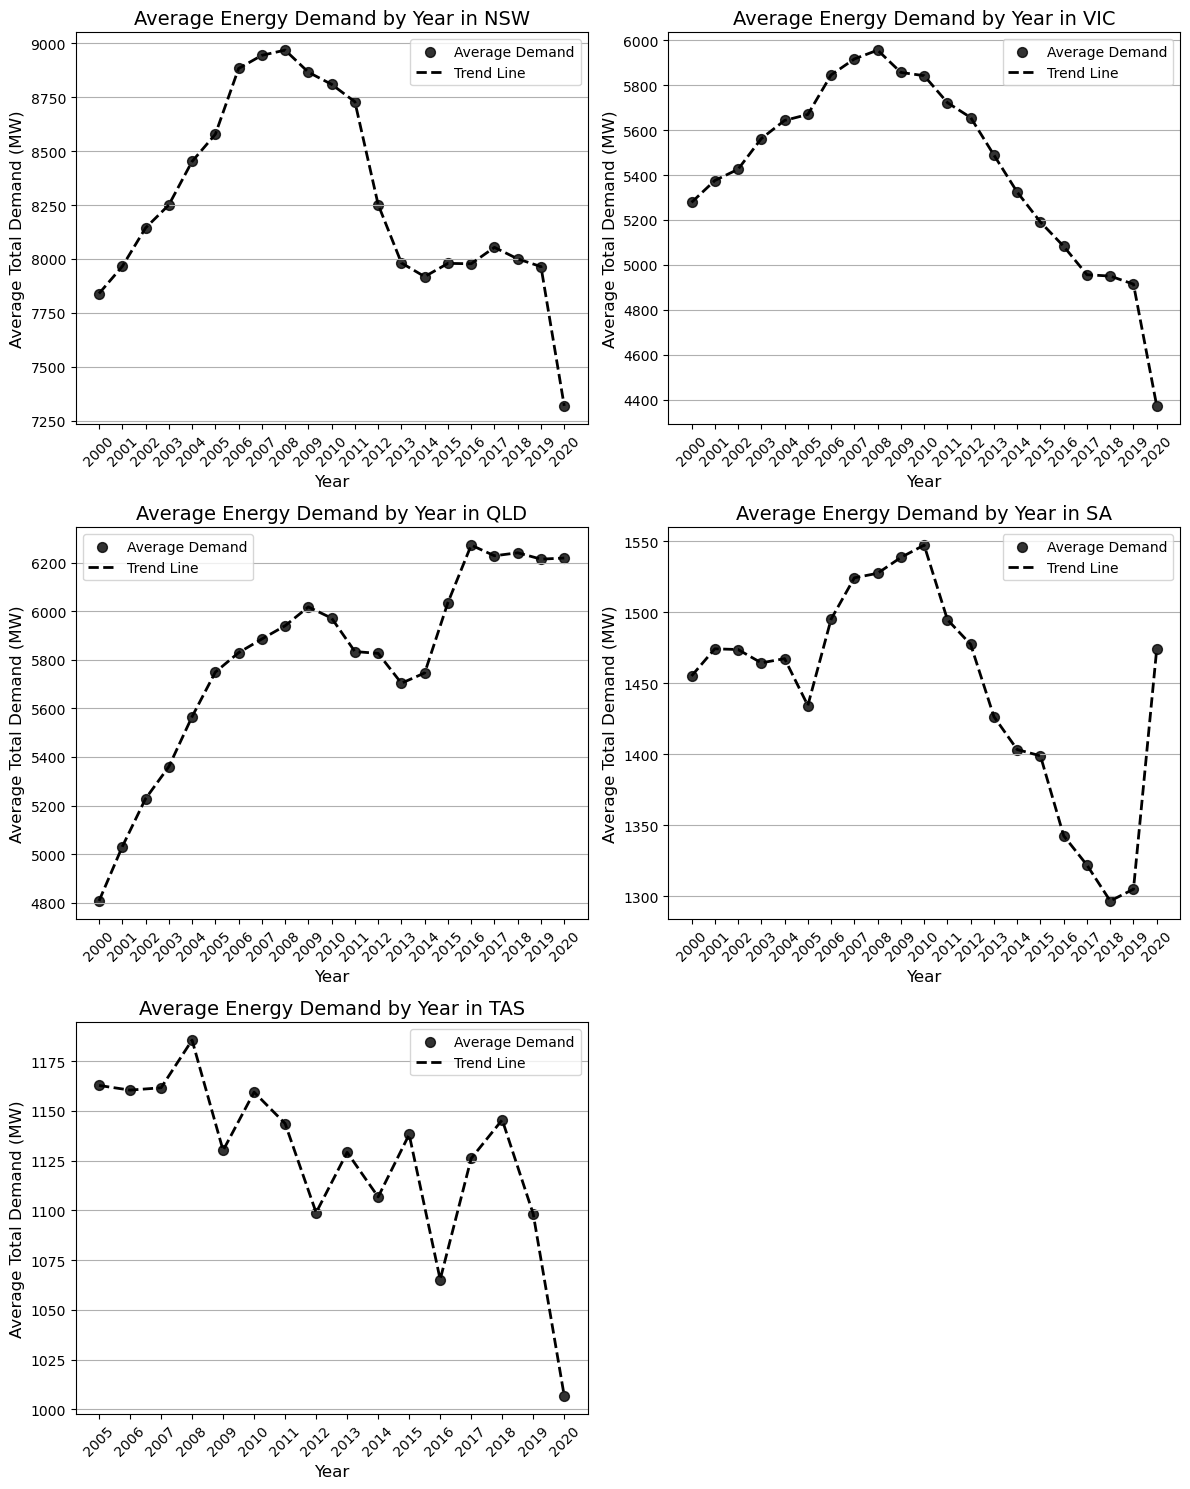

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# Load and prepare data (assuming master_data.csv has all states in long format)
demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/master_data.csv")
df = pd.read_csv(demand[0])

# Parse datetime and extract Year
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%Y/%m/%d %H:%M")
df['Year'] = df['Datetime'].dt.year

# States
states = ['NSW', 'VIC', 'QLD', 'SA', 'TAS']

# Create subplots: 3 rows (for 5 plots: 2 in first row, 2 in second,, 1 in third), 2 columns
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(12, 15), sharex=False)  # No shared x for flexibility

# Flatten axes for easier indexing
axes_flat = axes.flatten()

# Hide the unused 6th subplot (3x2=6, we need only 5)
axes_flat[5].axis('off')

for ax, state in zip(axes_flat[:5], states):
    # Filter data
    state_df = df[df['State'] == state]
    
    if state_df.empty:
        print(f"No data for {state}")
        continue
    
    # Average by year
    avg_demand_by_year = state_df.groupby('Year')['Total Demand'].mean().reset_index()
    avg_demand_by_year['Year'] = avg_demand_by_year['Year'].astype(int)
    
    # Plot
    ax.scatter(avg_demand_by_year['Year'], avg_demand_by_year['Total Demand'], 
               color='black', s=50, alpha=0.8, label='Average Demand')
    ax.plot(avg_demand_by_year['Year'], avg_demand_by_year['Total Demand'], 
            color='black', linewidth=2, linestyle='--', label='Trend Line')
    
    # Title and labels
    ax.set_title(f'Average Energy Demand by Year in {state}', fontsize=14)
    ax.set_ylabel('Average Total Demand (MW)', fontsize=12)
    ax.set_xlabel('Year', fontsize=12)  # Each graph now has its own x-label showing "Year"
    ax.grid(True, axis='y')
    ax.legend()
    
    # Set x-ticks to show integer years (this explicitly shows the years on x-axis)
    ax.set_xticks(avg_demand_by_year['Year'])
    ax.tick_params(axis='x', rotation=45)  # Rotate for better readability if years are dense

plt.tight_layout()
plt.show()

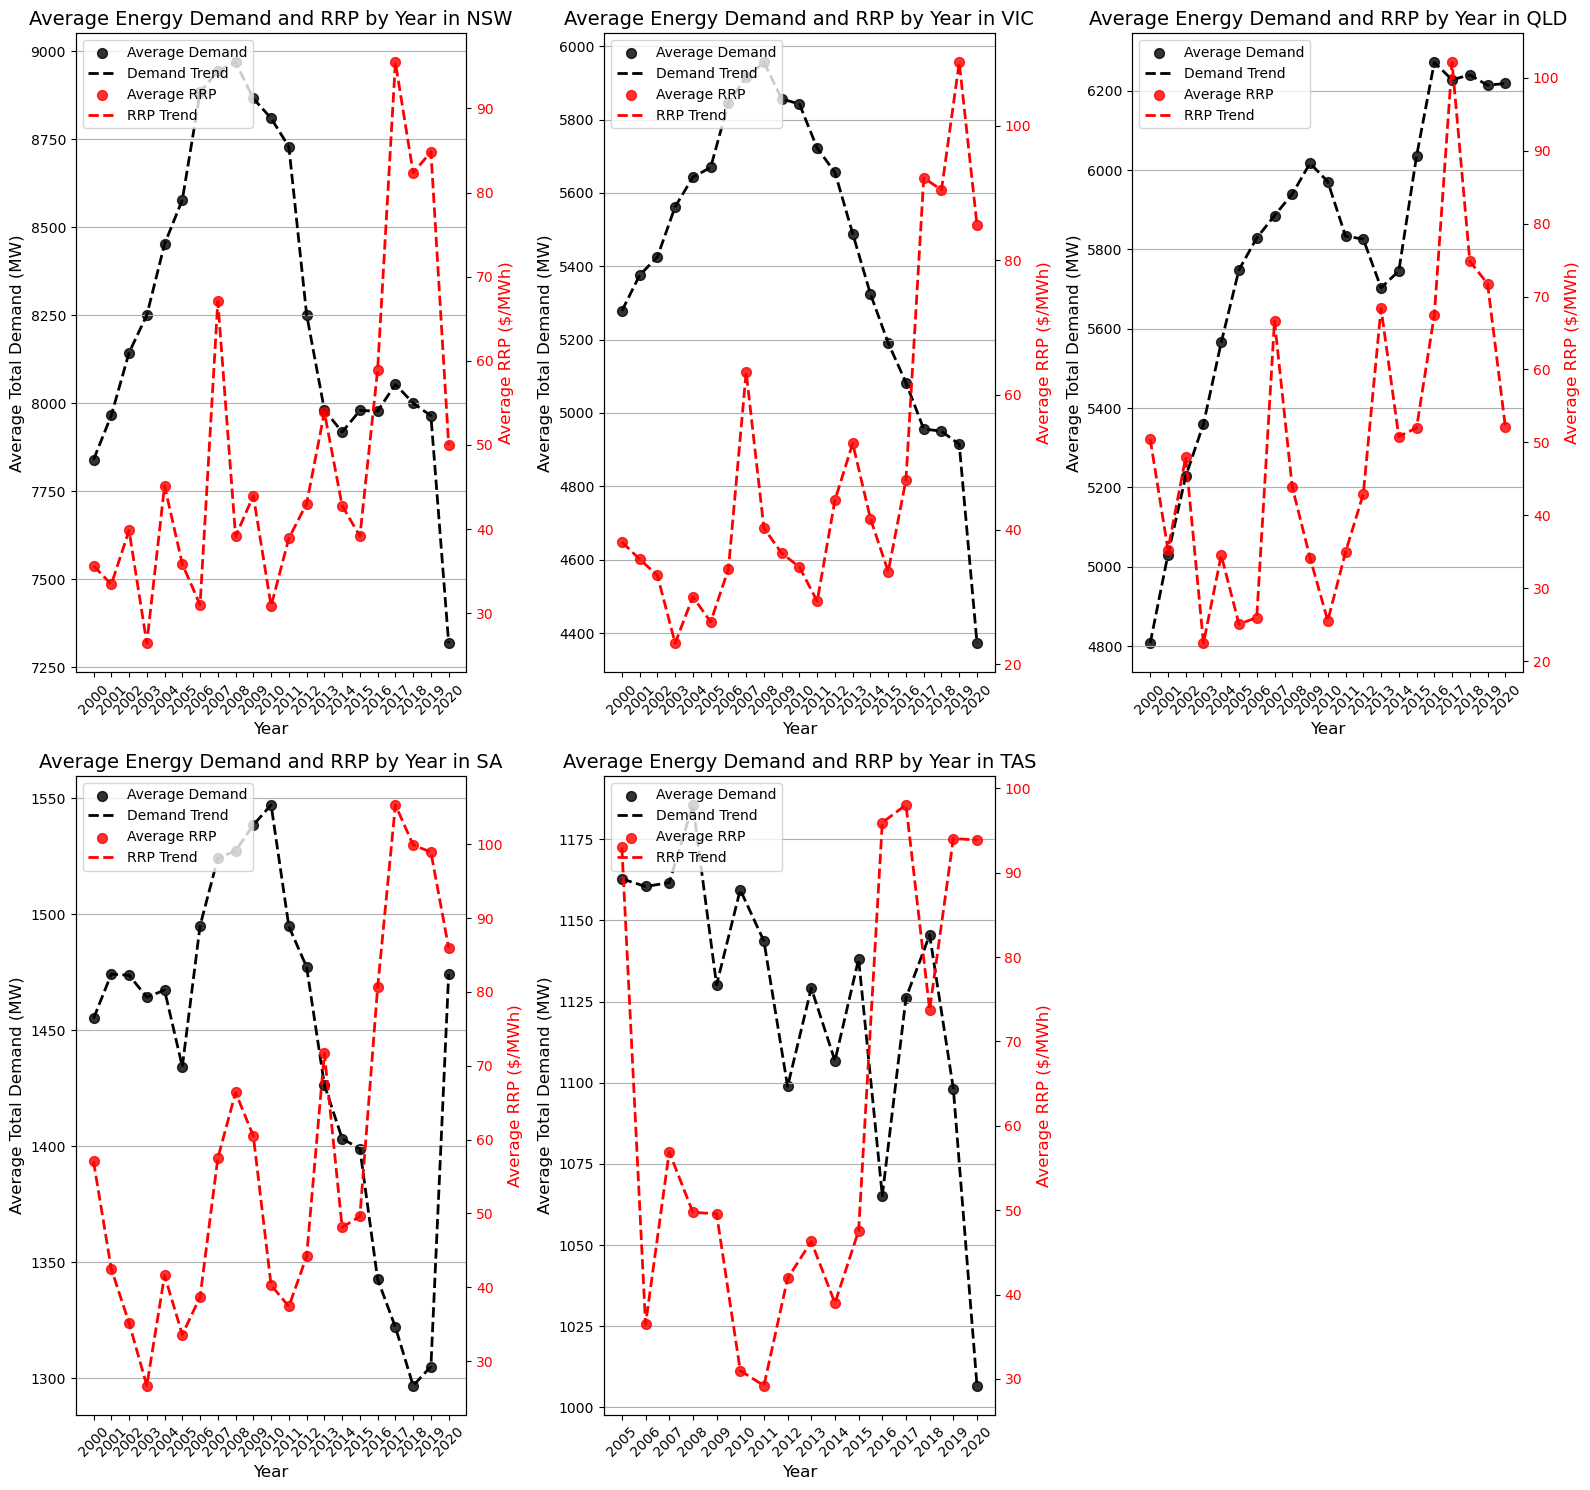

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

# Load and prepare data
demand = glob.glob("/Users/Coder/Desktop/ADS1002-project/data/processed/master_data.csv")
df = pd.read_csv(demand[0])

# Parse datetime and extract Year
df['Datetime'] = pd.to_datetime(df['Datetime'], format="%Y/%m/%d %H:%M")
df['Year'] = df['Datetime'].dt.year

# States
states = ['NSW', 'VIC', 'QLD', 'SA', 'TAS']

# Create subplots: 3 rows,  2 columns
fig, axes = plt.subplots(nrows=3, ncols=2, figsize=(16, 15), sharex=False)  # Increased width for dual y-axes

# Flatten axes
axes_flat = axes.flatten()

# Hide unused subplot
axes_flat[5].axis('off')

for ax, state in zip(axes_flat[:5], states):
    # Filter data
    state_df = df[df['State'] == state]
    
    if state_df.empty:
        print(f"No data for {state}")
        continue
    
    # Average Total Demand by year
    avg_demand_by_year = state_df.groupby('Year')['Total Demand'].mean().reset_index()
    avg_demand_by_year['Year'] = avg_demand_by_year['Year'].astype(int)
    
    # Average RRP by year
    avg_rrp_by_year = state_df.groupby('Year')['RRP'].mean().reset_index()
    avg_rrp_by_year['Year'] = avg_rrp_by_year['Year'].astype(int)
    
    # Primary y-axis: Total Demand (left)
    color_demand = 'black'
    ax.set_xlabel('Year', fontsize=12)
    ax.set_ylabel('Average Total Demand (MW)', fontsize=12, color=color_demand)
    ax.scatter(avg_demand_by_year['Year'], avg_demand_by_year['Total Demand'], 
               color=color_demand, s=50, alpha=0.8, label='Average Demand')
    ax.plot(avg_demand_by_year['Year'], avg_demand_by_year['Total Demand'], 
            color=color_demand, linewidth=2, linestyle='--', label='Demand Trend')
    ax.tick_params(axis='y', labelcolor=color_demand)
    ax.grid(True, axis='y')
    
    # Set x-ticks
    ax.set_xticks(avg_demand_by_year['Year'])
    ax.tick_params(axis='x', rotation=45)
    
    # Secondary y-axis: RRP (right)
    ax2 = ax.twinx()  # Share x-axis, new y-axis
    color_rrp = 'red'  # Distinct color for RRP
    ax2.set_ylabel('Average RRP ($/MWh)', fontsize=12, color=color_rrp)
    ax2.scatter(avg_rrp_by_year['Year'], avg_rrp_by_year['RRP'], 
                color=color_rrp, s=50, alpha=0.8, label='Average RRP')
    ax2.plot(avg_rrp_by_year['Year'], avg_rrp_by_year['RRP'], 
             color=color_rrp, linewidth=2, linestyle='--', label='RRP Trend')
    ax2.tick_params(axis='y', labelcolor=color_rrp)
    
    # Title
    ax.set_title(f'Average Energy Demand and RRP by Year in {state}', fontsize=14)
    
    # Legends: Combine both axes
    lines1, labels1 = ax.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.tight_layout()
plt.show()